# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [3]:
import sys
import pandas as pd
import sklearn
import mlflow
import evidently
import shap
import xgboost
import lightgbm

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)
print("Evidently:", evidently.__version__)
print("SHAP:", shap.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)

Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]
Pandas: 2.2.3
Scikit-Learn: 1.5.2
MLflow: 2.19.0
Evidently: 0.7.21
SHAP: 0.47.0
XGBoost: 2.1.3
LightGBM: 4.5.0


In [4]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [6]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    # fill in each column constraint
    "Type": Column(str, checks=Check.isin(['L', 'M', 'H'])),
    "Air temperature": Column(float, checks=Check.in_range(295.0, 305.0)),
    "Process temperature": Column(float, checks=Check.in_range(305.0, 315.0)),
    "Rotational speed": Column(int, checks=Check.in_range(1000, 2900)),
    "Torque": Column(float, checks=Check.in_range(3.0, 80.0)),
    "Tool wear": Column(int, checks=Check.in_range(0, 253)),
    "Failure_Type": Column(int, checks=Check.isin([0, 1, 2, 3, 4]))
},strict=True)

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)

print("Train and Current datasets validated successfully.")

# TODO: Validate stress with lazy=True and print violation summary

try:
    schema.validate(stress, lazy=True)
    print("Stress dataset validated successfully.")

except pa.errors.SchemaErrors as err:
    print("Schema violations found:")
    print(err.failure_cases)


Train and Current datasets validated successfully.
Stress dataset validated successfully.


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


   Failure_Type  Count  Percentage
0             0   6762       96.70
1             1     30        0.43
2             2     76        1.09
3             3     56        0.80
4             4     69        0.99


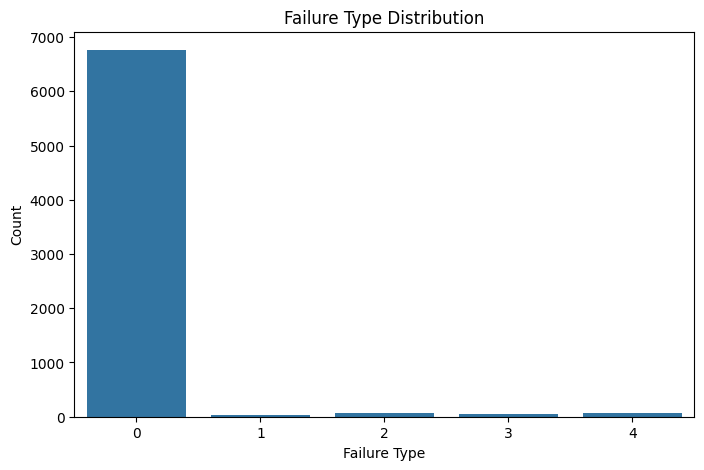

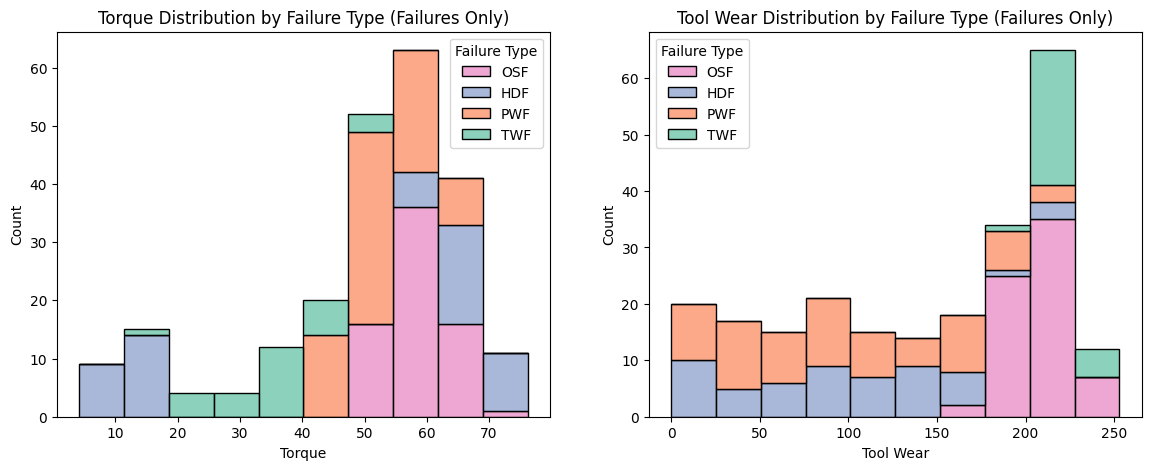

  Type  Count  Percentage
0    H    706       10.10
1    L   4213       60.25
2    M   2074       29.66


In [21]:
# TODO: Class distribution (print + bar chart)
failure_counts = train['Failure_Type'].value_counts().sort_index()
failure_count_prct = round(failure_counts / failure_counts.sum() * 100, 2)
display_df = pd.DataFrame({
    'Failure_Type': failure_counts.index,
    'Count': failure_counts.values,
    'Percentage': failure_count_prct.values
})
print(display_df)   # print the counts and percentages - Failure_Type distribution

plt.figure(figsize=(8, 5))
sns.barplot(x='Failure_Type', y='Count', data=display_df)
plt.title('Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.show()

# TODO: Torque distribution by failure type (histogram, failures only)

train_failures = train[train['Failure_Type'] != 0]  # Filter out no failures



fig, axes = plt.subplots(1, 2, figsize=(14,5))

# plt.figure(figsize=(10, 6))
sns.histplot(data=train_failures, x='Torque', hue='Failure_Type', multiple='stack', bins=10, palette='Set2',ax=axes[0])
axes[0].set_title('Torque Distribution by Failure Type (Failures Only)')
axes[0].set_xlabel('Torque')
axes[0].set_ylabel('Count')
axes[0].legend(title='Failure Type', labels=[CLASS_NAMES[i] for i in train_failures['Failure_Type'].unique()])
# plt.show()



# TODO: Tool wear distribution by failure 

# plt.figure(figsize=(10, 6))
sns.histplot(data=train_failures, x='Tool wear', hue='Failure_Type', multiple='stack', bins=10, palette='Set2',ax=axes[1])
axes[1].set_title('Tool Wear Distribution by Failure Type (Failures Only)')
axes[1].set_xlabel('Tool Wear')
axes[1].set_ylabel('Count')
axes[1].legend(title='Failure Type', labels=[CLASS_NAMES[i] for i in train_failures['Failure_Type'].unique()])

plt.savefig("artifacts/eda_distributions.png")

plt.show()

# TODO: Type distribution

type_counts = train['Type'].value_counts().sort_index()
type_count_prct = round(type_counts / type_counts.sum() * 100, 2)
display_type_df = pd.DataFrame({
    'Type': type_counts.index,
    'Count': type_counts.values,
    'Percentage': type_count_prct.values
})
print(display_type_df)   # print the counts and percentages - Type distribution


### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [24]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * df['Rotational speed'] * (2 * np.pi / 60)  # Power in Watts
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature'] # Temperature differential
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
grouped_mean = train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean()
print(grouped_mean.round(2))


              Power_W  Temp_diff
Failure_Type                    
0             6248.24      10.01
1             5763.09       9.97
2             7403.55       8.23
3             6664.38       9.82
4             8216.07      10.07


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import joblib

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts().sort_index())

print("Original Training Shape:", X_train.shape)
print("Resampled Training Shape:", X_train_resampled.shape)
print("Validation Shape:", X_val.shape)



joblib.dump(
    le,
    "artifacts/label_encoder.pkl"
)

Class distribution after SMOTE:
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64
Original Training Shape: (5594, 8)
Resampled Training Shape: (27045, 8)
Validation Shape: (1399, 8)


['artifacts/label_encoder.pkl']

*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE is applied only on the training data to prevent data leakage. Applying SMOTE before the train-validation split would allow synthetic information derived from the training set to appear in the validation set, resulting in overly optimistic performance estimates.

The validation set should represent unseen real-world data and therefore must retain its original class distribution to provide an unbiased evaluation of model performance.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [32]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report
import pandas as pd

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])

comparison_results = []

for model_name, model in models_to_run.items():

    with mlflow.start_run(run_name=model_name):

        # Train
        model.fit(
            X_train_resampled,
            y_train_resampled
        )

        # Predict
        y_pred = model.predict(X_val)

        # Metrics
        macro_f1 = f1_score(
            y_val,
            y_pred,
            average='macro'
        )

        weighted_f1 = f1_score(
            y_val,
            y_pred,
            average='weighted'
        )

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        per_class_f1 = f1_score(
            y_val,
            y_pred,
            average=None,
            labels=CLASS_LIST
        )

        # Log params
        mlflow.log_param(
            "model",
            model_name
        )

        # Log metrics
        mlflow.log_metric(
            "macro_f1",
            macro_f1
        )

        mlflow.log_metric(
            "weighted_f1",
            weighted_f1
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        # Per-class F1
        for i, score in enumerate(per_class_f1):
            mlflow.log_metric(
                f"f1_class_{i}",
                score
            )

        # Log model artifact
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            input_example=X_val.iloc[:5]
        )

        # Save for comparison table
        comparison_results.append({
            "Model": model_name,
            "Macro_F1": macro_f1,
            "Weighted_F1": weighted_f1,
            "Accuracy": accuracy
        })

# TODO: Print comparison table
comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    comparison_df.round(4)
)

# TODO: Identify best model by macro F1


best_model_name = (
    comparison_df
    .iloc[0]["Model"]
)

best_macro_f1 = (
    comparison_df
    .iloc[0]["Macro_F1"]
)

print(
    f"Best Model: {best_model_name}"
)

print(
    f"Macro F1: {best_macro_f1:.4f}"
)


,Model,Macro_F1,Weighted_F1,Accuracy
0,XGBoost,0.7481,0.9851,0.9843
1,RandomForest,0.7355,0.9855,0.9850
2,LightGBM,0.7296,0.9851,0.9843
3,LogisticRegression,0.5312,0.9328,0.9042


Best Model: XGBoost
Macro F1: 0.7481


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [33]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val

    model = XGBClassifier(**params)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)

    macro_f1 = f1_score(y_val, y_pred, average='macro')

    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
study.optimize(objective, n_trials=30)

print(study.best_value)
print(study.best_params)

# TODO: Train final best model
opt_best_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)

opt_best_model.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred = opt_best_model.predict(X_val)

opt_best_macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro"
)

print("Best Macro F1:", opt_best_macro_f1)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias

opt_best_weighted_f1 = f1_score(
            y_val,
            y_pred,
            average='weighted'
        )

opt_best_accuracy = accuracy_score(
    y_val,
    y_pred
)

opt_best_per_class_f1 = f1_score(
    y_val,
    y_pred,
    average=None,
    labels=CLASS_LIST
)

with mlflow.start_run(run_name="Tuned_XGBoost"):

    # Log params
    mlflow.log_param(
        "model",
        'PredMaint_XGBoost' # model_name
    )

    mlflow.log_params(study.best_params)

    # Log metrics
    mlflow.log_metric(
        "macro_f1",
        opt_best_macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        opt_best_weighted_f1
    )

    mlflow.log_metric(
        "accuracy",
        opt_best_accuracy
    )

    # Per-class F1
    for i, score in enumerate(opt_best_per_class_f1):
        mlflow.log_metric(
            f"f1_class_{i}",
            score
        )

    # Log model artifact
    mlflow.sklearn.log_model(
        opt_best_model,
        artifact_path="model",
        input_example=X_val.iloc[:5]
    )

    run_id = mlflow.active_run().info.run_id

# baseline_macro_f1 = 0.7481

improvement = opt_best_macro_f1 - best_macro_f1

print(f"Baseline Macro-F1 : {best_macro_f1:.4f}")
print(f"Tuned Macro-F1    : {opt_best_macro_f1:.4f}")
print(f"Improvement       : {improvement:.4f}")

from mlflow import MlflowClient
client = MlflowClient()

model_uri = f"runs:/{run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="PredMaint_XGBoost"
)

client.set_registered_model_alias(
    name="PredMaint_XGBoost",
    alias="production",
    version=registered_model.version
)

print("Registered Model :", registered_model.name)
print("Version          :", registered_model.version)
print("Alias            : production")

# TODO: Save with joblib.dump
joblib.dump(opt_best_model, 'artifacts/best_model.pkl')

0.7609903293491576
{'n_estimators': 462, 'max_depth': 4, 'learning_rate': 0.08853874505145662, 'min_child_weight': 6.83456102352091, 'subsample': 0.6473544266888274, 'colsample_bytree': 0.8745534255937363, 'gamma': 0.47778375377411253, 'reg_alpha': 1.9045113036901531e-07, 'reg_lambda': 0.0007066255503193089}
Best Macro F1: 0.7609903293491576


Baseline Macro-F1 : 0.7481
Tuned Macro-F1    : 0.7610
Improvement       : 0.0129


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


Registered Model : PredMaint_XGBoost
Version          : 1
Alias            : production


['artifacts/best_model.pkl']

## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [34]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary

# Create report
current_report = Report(
    metrics=[DataDriftPreset()]
)

# Run report
current_report.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS]
)

# Save HTML report
current_report.save_html("artifacts/drift_current.html")

report_dict = current_report.as_dict()

drift_result = report_dict["metrics"][0]["result"]

print("Dataset Drift Detected :", drift_result["dataset_drift"])
print("Number of Drifted Features :", drift_result["number_of_drifted_columns"])
print("Total Features Compared :", drift_result["number_of_columns"])


Dataset Drift Detected : False
Number of Drifted Features : 0
Total Features Compared : 5


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [35]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics

stress_report = Report(
    metrics=[
        DatasetDriftMetric(),
        ColumnDriftMetric(column_name='Air temperature'),
        ColumnDriftMetric(column_name='Process temperature'),
        ColumnDriftMetric(column_name='Rotational speed'),
        ColumnDriftMetric(column_name='Torque'),
        ColumnDriftMetric(column_name='Tool wear')
    ]
)

stress_report.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)

# TODO: Save drift_stress.html

stress_report.save_html(
    "artifacts/drift_stress.html"
)
# TODO: Print per-column drift table
report_dict = stress_report.as_dict()

rows = []

for metric in report_dict["metrics"][1:]:

    result = metric["result"]

    feature = result["column_name"]

    rows.append({
        "Feature": feature,
        "Drift Detected": result["drift_detected"],
        "Wasserstein Score": round(result["drift_score"], 4),
        "Reference Mean": round(train[feature].mean(), 2),
        "Current Mean": round(stress[feature].mean(), 2),
        "Delta": round(
            stress[feature].mean()
            - train[feature].mean(),
            2
        )
    })

drift_df = pd.DataFrame(rows)

display(drift_df)

,Feature,Drift Detected,Wasserstein Score,Reference Mean,Current Mean,Delta
0,Air temperature,False,0.0344,300.01,300.05,0.04
1,Process temperature,False,0.0377,310.00,310.01,0.00
2,Rotational speed,True,0.2354,1539.02,1497.07,-41.94
3,Torque,True,0.4739,40.00,44.72,4.73
4,Tool wear,True,0.6455,107.68,148.87,41.19


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: Rotational speed, Torque, Tool wear.

2. Most likely failure type to increase: Tool wear exhibited the largest distribution shift in the stress dataset during Evidently run.  As per SHAP analysis results Tool wear is the top feature influencing TWF and OSF. Therefore Tool wear failure and Overstrain failure will increase under stress conditions.

3. Retraining recommendation: Recommended - The current batch showed no dataset drift indicating that the deployed model remains suitable for normal operating conditions. However the stress batch exhibited significant drift in Rotational speed, Torque, and Tool wear. As SHAP identified Tool wear and Torque as most important features influencing TWF, OSF and Rotational speed as the second most influening feature for HDF type, the model is at risk of becoming stale under stress conditions. Retraining the model using more recent stress-condition data is recommended before continued deployment in such environments.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

SHAP shape (6993, 8, 5)


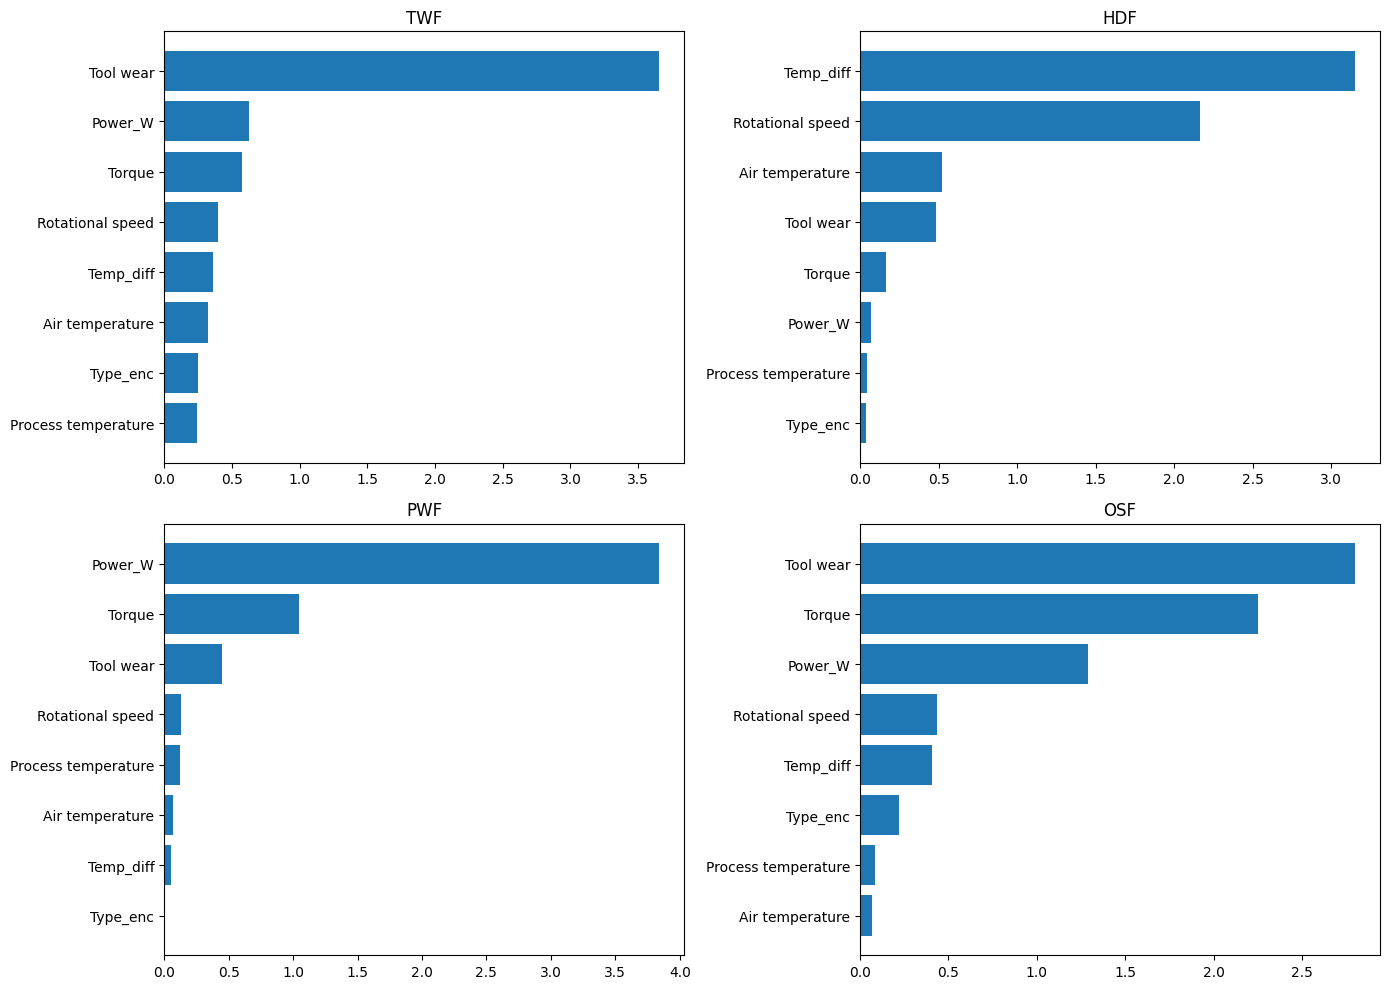

Top Driver per Failure Class

TWF : Tool wear
HDF : Temp_diff
PWF : Power_W
OSF : Tool wear


<Figure size 640x480 with 0 Axes>

In [36]:
import shap

best_model = joblib.load('artifacts/best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(train[FEATURES])
print("SHAP shape", shap_values.shape)

# TODO: Plot 4-subplot bar chart (one per failure class)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

failure_classes = [1, 2, 3, 4]

for ax, class_id in zip(axes.flatten(), failure_classes):

    mean_abs_shap = np.abs(shap_values[:, :, class_id]).mean(axis=0)

    importance_df = (
        pd.DataFrame({
            "Feature": FEATURES,
            "Importance": mean_abs_shap
        })
        .sort_values("Importance", ascending=True)
    )

    ax.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    ax.set_title(CLASS_NAMES[class_id])

plt.tight_layout()
plt.show()

# TODO: Save shap_per_class.png
plt.savefig("artifacts/shap_per_class.png")

# TODO: Print top driver per class

print("Top Driver per Failure Class\n")

for class_id in failure_classes:

    mean_abs_shap = np.abs(shap_values[:, :, class_id]).mean(axis=0)

    top_feature = FEATURES[np.argmax(mean_abs_shap)]

    print(f"{CLASS_NAMES[class_id]} : {top_feature}")


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: The derived feature Power_W is the most influencial feature for PWF. Torque & Rotational speed comes second and fourth respectively. 

2. Temp_diff for HDF: Temp_diff ranked as the most important feature for Heat Dissipation Failure (HDF). For other Failure types, Temp_diff is in the bottom half of the SHAP Plot indicating it doesnt influence those failure types as such. 

3. Physical mechanisms: 

    **Condition:** Increased Tool wear observed during machine operation.  
    **Risked failure class:** Tool Wear Failure (TWF) and Overstrain Failure (OSF).  
    **Action:** Increase tool and lubricant quality inspection frequency, verify lubrication schedule, perform preventive tool replacement, and closely monitor machines operating with high tool wear.

    **Condition:** Increased Torque or abnormal Power_W values indicating higher mechanical load.  
    **Risked failure class:** Power Failure (PWF) and Overstrain Failure (OSF).  
    **Action:** Monitor machine load conditions and perform cause analysis on abnormal torque or power consumption patterns.

    **Condition:** Increased Temp_diff indicating abnormal heat dissipation behavior.  
    **Risked failure class:** Heat Dissipation Failure (HDF).  
    **Action:** Inspect cooling systems, verify coolant and lubricant condition, and perform preventive maintenance on thermal management components.


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
XGBoost was selected as the best performing model based on macro F1 score. Although multiple models achieved high accuracy, XGBoost provided the strongest balance across failure classes with a baseline Macro-F1 score of 0.7481. After Optuna hyperparameter tuning, the XGBoost model improved to a Macro-F1 score of 0.7610 and was registered as the production model.


**2. Accuracy vs Macro F1:**
Accuracy alone was misleading for this predictive maintenance problem because the dataset was highly imbalanced, with the majority of records belonging to the no-failure class. A model could achieve high accuracy by correctly predicting normal machine operation while failing to identify rare failure types.From an operational cost perspective, missing a failure prediction (false negative) is much more expensive than a false alarm. For a manufacturer operating 10,000+ machines, an undetected failure can stop production and result in downtime costs of ₹8–15 lakh per hour. Therefore, optimizing the model to identify rare failures is more valuable than maximizing overall accuracy. Macro-F1 was selected as the primary metric because it gives equal importance to each failure class and better represents performance on rare but operationally important machine failures.


**3. The TWF problem:**
Tool Wear Failure (TWF) remained challenging due to severe data scarcity, with only 30 original samples available. Although SMOTE helped balance the training dataset by creating synthetic samples, it cannot replace the information contained in real failure examples. The recommended fix is to collect additional real-world TWF failure data, including tool age, operating conditions, maintenance history, lubrication quality, and sensor readings before failure events.


**4. Drift and maintenance schedule:**
The stress batch showed significant drift in Rotational speed, Torque, and Tool wear. Since these features are important predictors according to SHAP analysis, the model may become stale when machines operate under stress conditions. Continuous drift monitoring should be implemented, and model retraining should be triggered when important operational features shift significantly.


**5. Actionable recommendation:**
**Condition:** Increased Tool wear observed or machines operating with high tool usage duration.  
**Risked failure class:** Tool Wear Failure (TWF) and Overstrain Failure (OSF).  
**Action:** Increase tool inspection frequency, verify lubrication process and lubricant quality, schedule preventive tool replacement, and monitor high-wear machines.


### EDA Findings

The target variable is highly imbalanced, with 96.7% of observations corresponding to normal machine operation (Failure_Type = 0). The failure classes are rare, particularly Failure_Type = 1, which contains only 30 observations.

This imbalance indicates that accuracy alone would be a misleading evaluation metric because a model could achieve high accuracy while failing to detect rare machine failures. Therefore, later sections will use SMOTE and macro-F1 score for model selection.

The Torque and Tool wear distributions differ across failure types, suggesting that different failure mechanisms are associated with distinct operational conditions. These variables are likely to be important predictors and will be further examined using SHAP explainability.

The machine Type distribution is also imbalanced, with low-load machines representing approximately 60% of the observations.


### Feature Engineering Findings

Two physically meaningful features were created:

- **Power_W** combines torque and rotational speed to represent the machine's mechanical power consumption.
- **Temp_diff** represents the temperature difference between process and ambient conditions.

The grouped means show that failure modes operate under different mechanical and thermal conditions. In particular, Failure_Type 4 exhibits the highest average power consumption, suggesting a relationship between high mechanical load and certain failure modes.

These engineered features may improve predictive performance and could become important explanatory variables in the SHAP analysis.

### SMOTE Findings

After the stratified 80/20 split, the training dataset contained 5,594 observations and the validation dataset contained 1,399 observations.

SMOTE was applied only to the training split and successfully balanced all five classes to 5,409 observations each, resulting in a resampled training dataset of 27,045 observations.

Balancing the training data helps the models learn rare failure patterns and improves the usefulness of metrics such as macro-F1 score. However, synthetic oversampling cannot completely replace the diversity of real observations, particularly for extremely rare failure classes.


### Initial Model Training


### Hyperparameter Tuning and Model Registration

An Optuna study with 30 trials was conducted to optimize the XGBoost hyperparameters using Macro-F1 as the optimization objective. The tuned model achieved a Macro-F1 score of **0.7610**, improving upon the baseline XGBoost score of **0.7481** by **0.0129**.

The tuned model was logged to MLflow together with its optimized hyperparameters and evaluation metrics. It was then registered as **PredMaint_XGBoost**, assigned **Version 1**, and promoted to the **production** alias. Finally, the trained model was also saved locally as **artifacts/best_model.pkl** for future deployment or inference.


### Current Batch Drift Analysis

The training dataset was used as the reference distribution and the current batch as the comparison dataset. Evidently's DataDriftPreset detected **no dataset drift**, with **0 out of 5 monitored features** exhibiting statistically significant drift.

This indicates that the current production data closely matches the training data distribution, suggesting that the deployed model remains applicable for the current operating conditions. The generated drift report was saved as **artifacts/drift_current.html** for further analysis.


### Stress Batch Drift Analysis

The stress dataset was compared against the training dataset using Evidently's DatasetDriftMetric and ColumnDriftMetric.

No statistically significant drift was observed for **Air temperature** or **Process temperature**, indicating that environmental conditions remained consistent with the training data.

However, **Rotational speed**, **Torque**, and **Tool wear** exhibited significant drift. Tool wear showed the largest distribution shift (Wasserstein score = 0.6455), followed by Torque (0.4739) and Rotational speed (0.2354). These changes suggest that the deployed model is receiving operating conditions that differ substantially from those seen during training, increasing the risk of model staleness and reduced predictive performance.


### SHAP Analysis Per Failure Class

SHAP values were computed using TreeExplainer on the tuned XGBoost model to identify the most influential features for each failure class.

The analysis showed that **Tool wear** is the dominant predictor for both **Tool Wear Failure (TWF)** and **Overstrain Failure (OSF)**. **Temperature differential (Temp_diff)** is the most influential feature for **Heat Dissipation Failure (HDF)**, while **Mechanical Power (Power_W)** is the strongest predictor for **Power Failure (PWF)**.

These results demonstrate that different failure mechanisms are driven by different operational factors. Therefore, SHAP explanations should be interpreted separately for each failure class rather than using a single global feature ranking.